<a href="https://colab.research.google.com/github/bjseifert/clustering-hands-on/blob/main/deep_learning_architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.main(x)

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


for epoch in range(5):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.12MB/s]


Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.


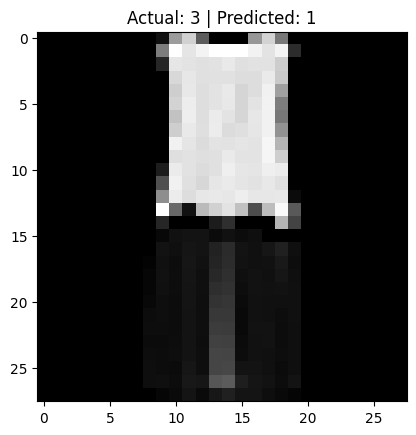

In [29]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
output = model(images)
_, predicted = torch.max(output, 1)

plt.imshow(images[0].reshape(28, 28), cmap='gray')
plt.title(f"Actual: {labels[0].item()} | Predicted: {predicted[0].item()}")
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.main(x)

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


for epoch in range(5):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete.")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.84MB/s]


Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.


In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Linear(32 * 13 * 13, 10)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

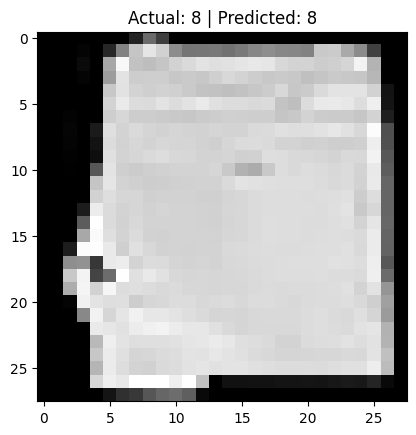

In [27]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
output = model(images)
_, predicted = torch.max(output, 1)

plt.imshow(images[0].reshape(28, 28), cmap='gray')
plt.title(f"Actual: {labels[0].item()} | Predicted: {predicted[0].item()}")
plt.show()

In [16]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1) # Binary Sentiment
        self.sig = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        return self.sig(self.fc(hidden[-1]))

In [31]:
import torch
import torch.nn as nn

sentences = ["i loved this movie", "this was terrible", "great acting", "bad plot"]
labels = torch.tensor([1, 0, 1, 0], dtype=torch.float32)

vocab = {"<PAD>": 0, "i": 1, "loved": 2, "this": 3, "movie": 4, "was": 5, "terrible": 6, "great": 7, "acting": 8, "bad": 9, "plot": 10}

In [32]:
class SimpleLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SimpleLSTM, self).__init__()
        # Embedding turns a word number into a vector of features
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # LSTM processes the sequence
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        # Final layer to pick 0 or 1
        self.fc = nn.Linear(hidden_dim, 1)
        self.sig = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        out, (hidden, cell) = self.lstm(x)
        # We only care about the very last word's output
        return self.sig(self.fc(hidden[-1]))

# Initialize
model_rnn = SimpleLSTM(vocab_size=len(vocab), embed_dim=8, hidden_dim=16)
print("RNN Model Built!")

RNN Model Built!


In [33]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=0.01)

for epoch in range(10):

    pass

In [34]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)

netG = Generator()
netD = Discriminator()

In [35]:
criterion = nn.BCELoss()
optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0002)
optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0002)

for epoch in range(10):
    for i, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.size(0)

        netD.zero_grad()
        label_real = torch.ones(batch_size, 1)
        output = netD(real_images)
        lossD_real = criterion(output, label_real)

        noise = torch.randn(batch_size, 100)
        fake_images = netG(noise)
        label_fake = torch.zeros(batch_size, 1)
        output = netD(fake_images.detach())
        lossD_fake = criterion(output, label_fake)
        (lossD_real + lossD_fake).backward()
        optimizerD.step()

        netG.zero_grad()
        output = netD(fake_images)
        lossG = criterion(output, label_real)
        lossG.backward()
        optimizerG.step()

    print(f"Epoch [{epoch+1}/10] complete!")

Epoch [1/10] complete!
Epoch [2/10] complete!
Epoch [3/10] complete!
Epoch [4/10] complete!
Epoch [5/10] complete!
Epoch [6/10] complete!
Epoch [7/10] complete!
Epoch [8/10] complete!
Epoch [9/10] complete!
Epoch [10/10] complete!


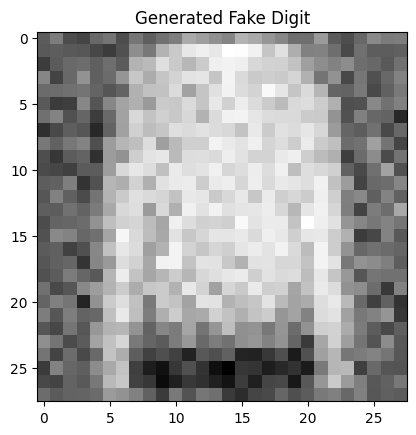

In [41]:
import matplotlib.pyplot as plt

noise = torch.randn(1, 100)
generated_img = netG(noise)
plt.imshow(generated_img.detach().numpy().reshape(28, 28), cmap='gray')
plt.title("Generated Fake Digit")
plt.show()